1. Learned Climate Regimes 

In [ ]:
import os, sys

if '..' not in sys.path:
    sys.path.append('..')
    os.chdir('..')
    
import pandas as pd
import torch
import numpy as np
import src.inference as inf
from src.el_nino import read_enso_data
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
import plotly.graph_objects as go

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
VALIDATION = True

config_file = "checkpoint/temperature_only/params-temperature-exp-2-c30.yaml"
save_path = "results/temperature-exp-2-c30"
model_suffix = None  #model_suffix=None for latest

In [3]:
params, dataset = inf.read_data(config_file,validation=VALIDATION)
target_encoder, prot = inf.load_model(params,model_suffix=model_suffix) 

E, F = inf.get_model_results(read_path=save_path,
                              params=params, dataset=dataset, encoder=target_encoder, prototypes=prot)

if VALIDATION:
    E_val, F_val = inf.get_model_results(read_path=save_path,
                                        params=params, dataset=dataset.validation_imgs, encoder=target_encoder, prototypes=prot,
                                        validation=True)
    
    
    tsne_E, tsne_prot, tsne_Eval = inf.get_TSNE(save_path, 
                                            E = E.cpu(), 
                                            prot = prot.cpu(),
                                            E_val = E_val.cpu() if VALIDATION else None,
                                            validation=VALIDATION)

INFO:root:data loader created
Loaded E and F from results/temperature-exp-2-c30
Loaded E and F from results/temperature-exp-2-c30


In [ ]:

cluster_prob, cluster_id = torch.max(F, dim=1) 
df = pd.DataFrame({"cluster_id": cluster_id.cpu(), "cluster_prob": cluster_prob.cpu(),
                   'sample_type':'train','date':dataset.time})

if VALIDATION:

    val_cluster_prob, val_cluster_id = torch.max(F_val, dim=1) # Obtém os valores máximos e seus índices
    df_val = pd.DataFrame({"cluster_id": val_cluster_id.cpu(),"cluster_prob": val_cluster_prob.cpu(),
                           'sample_type':'val','date':dataset.val_time})
        
    df =  pd.concat([df,df_val]).reset_index(drop=True) 
    df = df.sort_values('date')
    
    
    combined_dataset = torch.cat((dataset[:][0], dataset.validation_imgs))[df.index]
    tsne = np.concatenate((tsne_E, tsne_Eval))[df.index]
    
    mean = torch.tensor(params['data']['norm_means']).view(2, 1, 1)
    std = torch.tensor(params['data']['norm_stds']).view(2, 1, 1)
    combined_dataset = (combined_dataset*std)+mean

    df = df.reset_index(drop=True)  

else:
    combined_dataset = dataset[:][0]
    
oni_index = read_enso_data()

df_el_nino = df.copy()
df_el_nino['date_period'] = df_el_nino['date'].dt.to_period('M')
df_el_nino = df_el_nino.merge(oni_index, left_on='date_period', right_index=True, how='left')
df_el_nino.loc[:, ['Average Tmin', 'Average Tmax']] =  combined_dataset.mean(dim=(2,3))

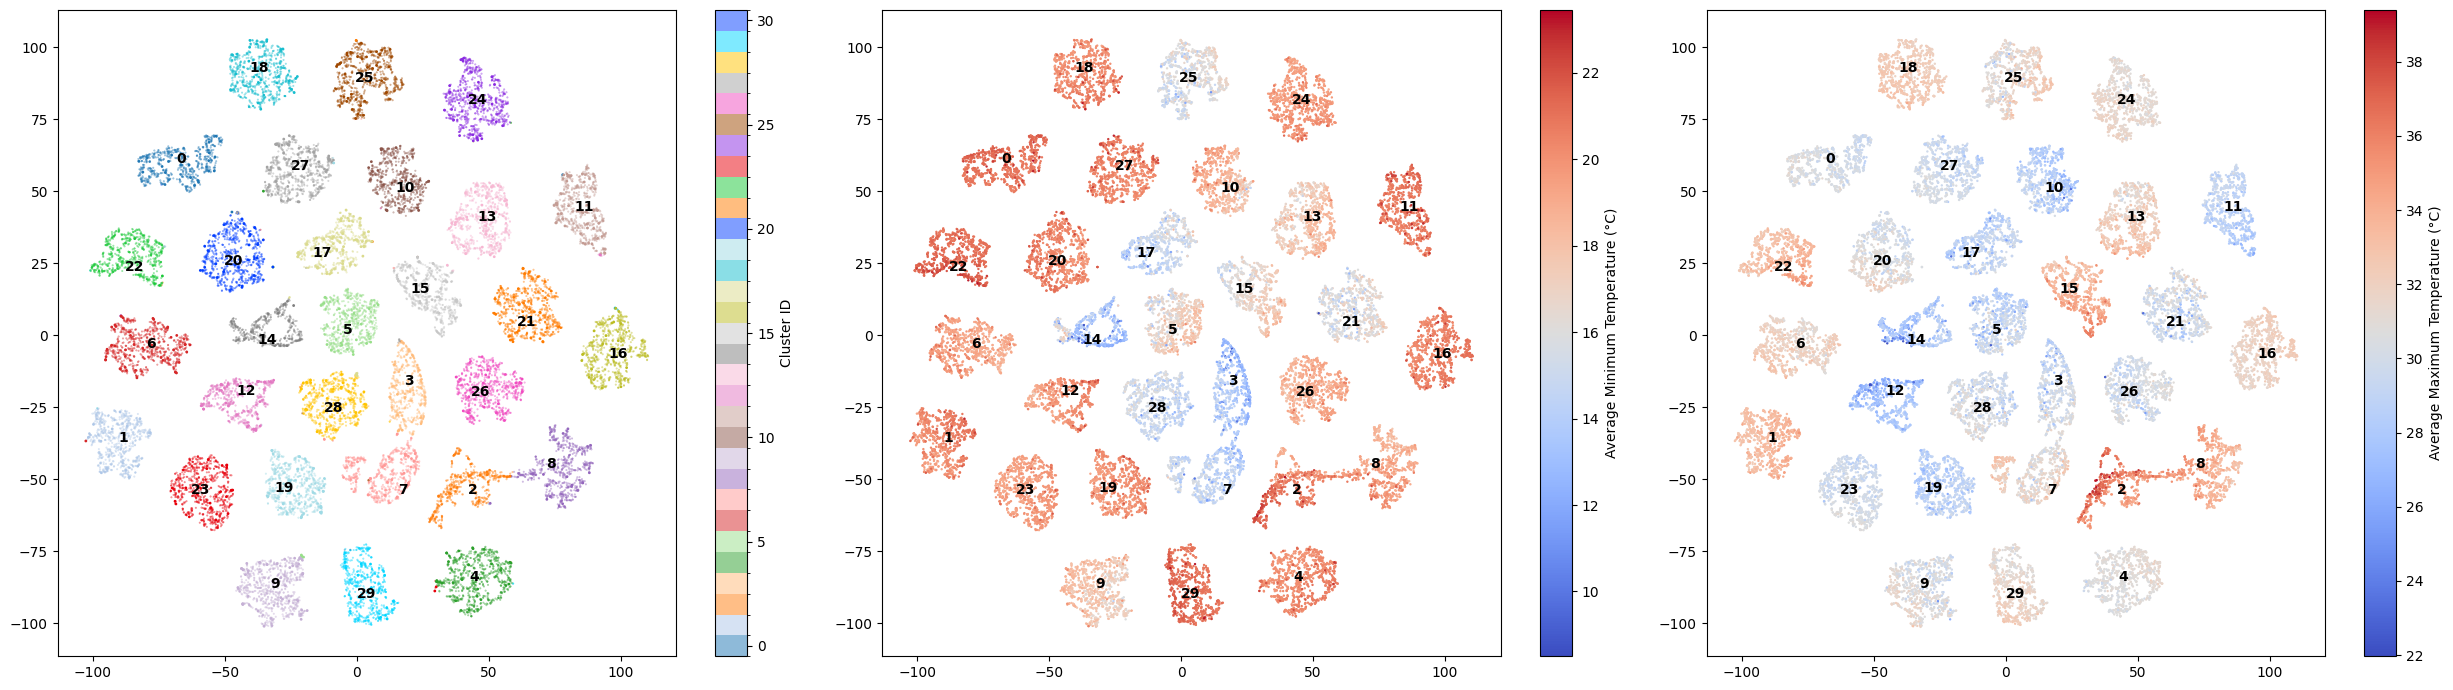

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
# Configuração do layout 2x2
fig, axs = plt.subplots(1, 3, figsize=(25, 7))
axs = axs.flatten()

# --- GRÁFICO 1: Clusters (Protótipos) ---
# cmap_clusters = plt.get_cmap('hsv', 31) 
cluster_labels = F.argmax(axis=1).cpu().numpy()

pallete31 = sns.color_palette("tab20", 20) + sns.color_palette("bright", 11)
cmap_clusters = mcolors.ListedColormap(pallete31)
bounds = np.arange(-0.5, 31.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap_clusters.N)

sc1 = axs[0].scatter(tsne_E[:, 0], tsne_E[:, 1], c=cluster_labels, 
                     cmap=cmap_clusters,norm=norm, s=0.2, alpha=0.5)

if VALIDATION:
    cluster_labels_val = F_val.argmax(axis=1).cpu().numpy()
    axs[0].scatter(tsne_Eval[:, 0], tsne_Eval[:, 1], c=cluster_labels_val, 
                   cmap=cmap_clusters,norm=norm,     s=1)

# Adiciona a colorbar discreta com 31 intervalos
cbar1 = fig.colorbar(sc1, ax=axs[0], ticks=np.arange(0, 31, 5))
cbar1.set_label('Cluster ID')

# Texto dos protótipos
for i, (x, y) in enumerate(tsne_prot):
    axs[0].text(x, y, str(i), color='black', fontsize=10, ha='center', va='center', weight='bold')


# --- GRÁFICO 2: Temperatura Mínima ---
oni_train = df_el_nino[df_el_nino['sample_type']=='train']['Average Tmin'].values
sc2 = axs[1].scatter(tsne_E[:, 0], tsne_E[:, 1], c=oni_train, 
                     cmap='coolwarm', s=0.5, alpha=1)

if VALIDATION:
    oni_val = df_el_nino[df_el_nino['sample_type']=='val']['Average Tmin'].values
    axs[1].scatter(tsne_Eval[:, 0], tsne_Eval[:, 1], c=oni_val, 
                   cmap='coolwarm', s=0.5, alpha=1)

fig.colorbar(sc2, ax=axs[1], label='Average Minimum Temperature (°C)')

for i, (x, y) in enumerate(tsne_prot):
    axs[1].text(x, y, str(i), color='black', fontsize=10, ha='center', va='center', weight='bold')

# --- GRÁFICO 3: Temperatura Máxima ---
temp_train = df_el_nino[df_el_nino['sample_type']=='train']['Average Tmax'].values
sc3 = axs[2].scatter(tsne_E[:, 0], tsne_E[:, 1], c=temp_train, 
                     cmap='coolwarm', s=0.5, alpha=1)

if VALIDATION:
    temp_val = df_el_nino[df_el_nino['sample_type']=='val']['Average Tmax'].values
    axs[2].scatter(tsne_Eval[:, 0], tsne_Eval[:, 1], c=temp_val, 
                   cmap='coolwarm', s=0.5, alpha=1)

fig.colorbar(sc3, ax=axs[2], label='Average Maximum Temperature (°C)')

for i, (x, y) in enumerate(tsne_prot):
    axs[2].text(x, y, str(i), color='black', fontsize=10, ha='center', va='center', weight='bold')


plt.tight_layout()
plt.show()

In [ ]:
nvars = combined_dataset.shape[1] 
N_PROTO = params['criterion']['num_proto']
vars_names = params['data']['surf_vars']

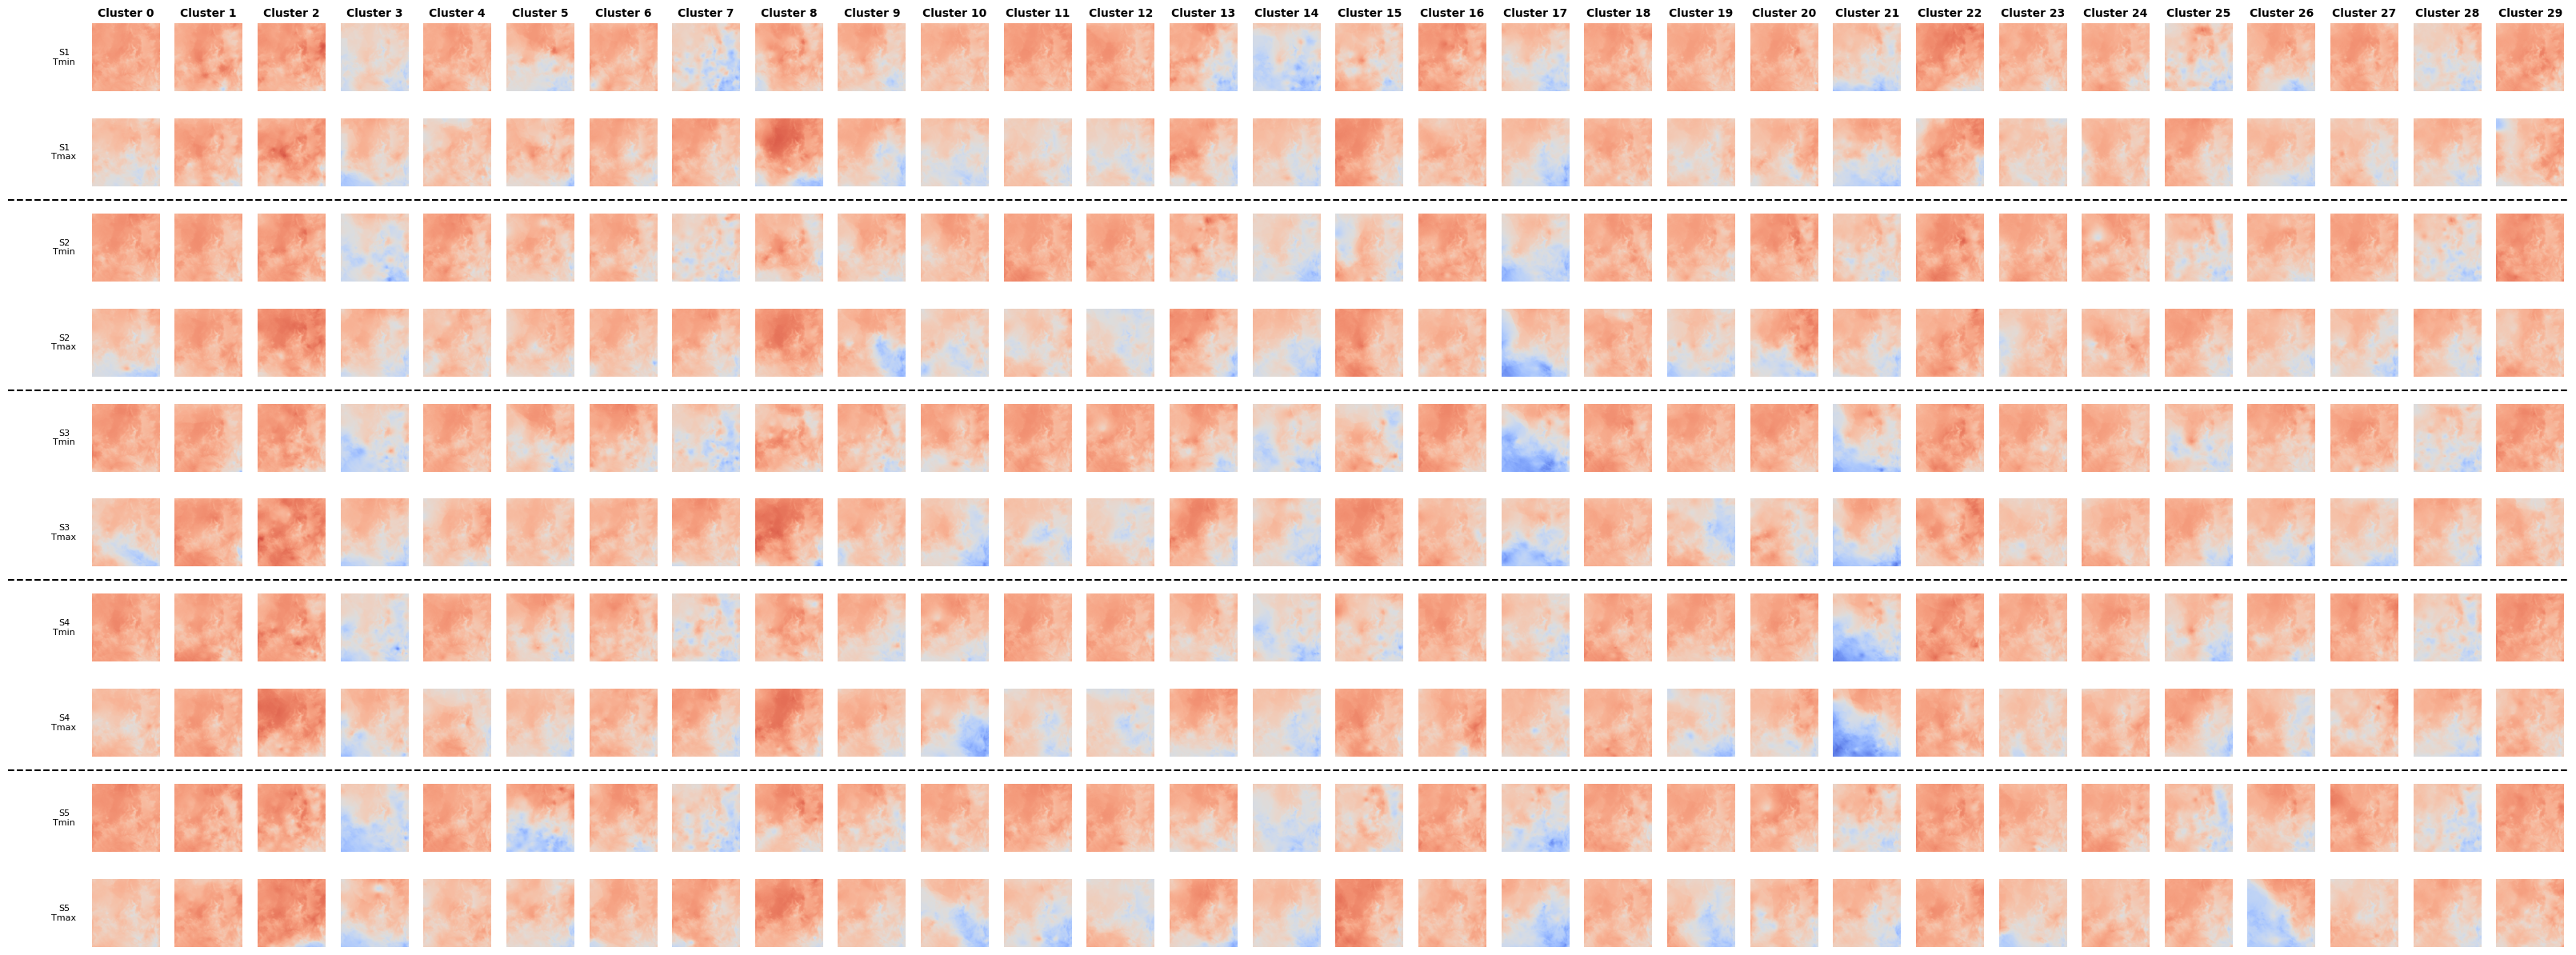

In [18]:
Top=5

# 1. Configuração da Grid: Colunas = Clusters, Linhas = (Samples * nvars)
n_cols = N_PROTO
n_rows = Top * nvars

fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 15))

var_stats = {}
for var in range(nvars):
    vmin, vmax = combined_dataset[:,var,:,:].min(), combined_dataset[:,var,:,:].max()
    var_stats[var] = (vmin, vmax)
    
# Ajuste fino de espaço para caber as linhas divisórias
plt.subplots_adjust(hspace=0.4, wspace=0.1)

for i in range(N_PROTO):
    # Pega os melhores samples do cluster atual
    top_samples = df[(df["cluster_id"] == i) & (df["sample_type"] == "train")].nlargest(Top, "cluster_prob")
    
    for s_idx, im_index in enumerate(top_samples.index):
        image_data = combined_dataset[im_index]
        row_offset = s_idx * nvars 
        
        for var in range(nvars):
            ax = axes[row_offset + var, i]
            vmin, vmax = var_stats[var]
            ax.imshow(image_data[var], cmap='coolwarm', vmin=vmin, vmax=vmax)
            
            # Título do Cluster apenas no topo
            if row_offset + var == 0:
                ax.set_title(f"Cluster {i}", fontsize=10, fontweight='bold')
            
            # Label da Variável apenas na primeira coluna
            if i == 0:
                ax.set_ylabel(f"S{s_idx+1}\n{vars_names[var]}", rotation=0, labelpad=25, va='center', fontsize=8)

# 2. Desenhar linhas horizontais entre os SAMPLES (a cada nvars linhas)
# Começamos de nvars até n_rows-1 para não riscar o topo/fundo
for r in range(nvars, n_rows, nvars):
    # Pegamos a posição entre a linha de baixo do sample anterior e a de cima do atual
    upper_ax = axes[r-1, 0].get_position()
    lower_ax = axes[r, 0].get_position()
    y_pos = (upper_ax.y0 + lower_ax.y1) / 2
    
    # Linha que atravessa a figura inteira
    line = plt.Line2D([0.1, 0.9], [y_pos, y_pos], 
                      transform=fig.transFigure, color="black", 
                      linewidth=1.5, linestyle='--')
    fig.add_artist(line)

# Limpeza final de eixos
for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


# plt.savefig("cluster_samples_grid.png", dpi=300)
plt.show()

Sazonalidade dos clusters

In [10]:
def get_season(date):
    month = date.month
    day = date.day

    # Verão: 21 ou 22 de dezembro a 20 ou 21 de março
    if (month == 12 and day >= 21) or \
       (month == 1 or month == 2) or \
       (month == 3 and day <= 20):
        return 'Summer'
    # Outono: 20 ou 21 de março a 20 ou 21 de junho
    elif (month == 3 and day >= 21) or \
         (month == 4 or month == 5) or \
         (month == 6 and day <= 20):
        return 'Autumn'
    # Inverno: 20 ou 21 de junho a 22 ou 23 de setembro
    elif (month == 6 and day >= 21) or \
         (month == 7 or month == 8) or \
         (month == 9 and day <= 22):
        return 'Winter'
    # Primavera: 22 ou 23 de setembro a 20 ou 21 de dezembro
    else: # (month == 9 and day >= 23) or (month == 10 or month == 11) or (month == 12 and day <= 20)
        return 'Spring'

# Aplique a função para criar uma nova coluna 'season'
df['season'] = df['date'].apply(get_season)
season_cluster_distribution = pd.crosstab(df['season'], df['cluster_id']).loc[['Spring','Summer','Autumn','Winter']]

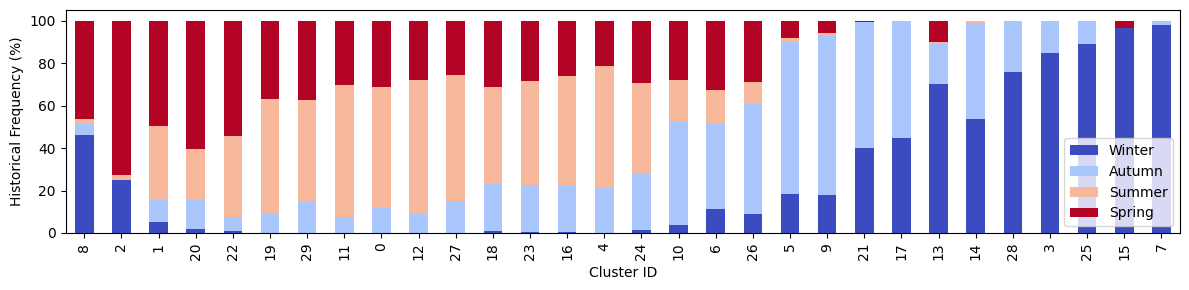

In [12]:
def seasonal_composition(df,order=None):

    season_order = ['Spring', 'Summer', 'Autumn', 'Winter'][::-1]
    df= df.copy()
    seasonal_dist = pd.crosstab(df['cluster_id'], df['season'], normalize='index')*100
    
    if not order:
        seasonal_dist['dominant'] = seasonal_dist.idxmax(axis=1)
        seasonal_dist['dominant'] = pd.Categorical(seasonal_dist['dominant'], categories=season_order, ordered=True)

        
        order_map = {s: i for i, s in enumerate(season_order)}
        def weighted_score(row):
            return sum(row[s] * order_map[s] for s in season_order)

        seasonal_dist['season_score'] = seasonal_dist.apply(weighted_score, axis=1)
        seasonal_dist.loc[seasonal_dist["dominant"]=="Spring","season_score"] *=-1
        seasonal_dist = seasonal_dist.sort_values(['dominant', 'season_score'], ascending=[True, True])

    else:
        seasonal_dist = seasonal_dist.loc[order]
        

    # 4. Plot Stacked Bar Chart
    seasonal_dist[::-1][season_order].plot(
        kind='bar', 
        stacked=True, 
        figsize=(12, 3), 
        colormap='coolwarm', # Red/Blue contrast usually looks good for seasons
        # width=0.8
    )

    # plt.title('Seasonal Composition of the 30 Climate States', fontsize=14)
    plt.ylabel('Historical Frequency (%)') #bbox_to_anchor=(1.05, 1),
    plt.xlabel('Cluster ID')
    plt.legend( loc='lower right')
    plt.tight_layout()
    plt.show()
    
    return list(seasonal_dist.index)

complete_data_order = seasonal_composition(df)

In [14]:
seasonal_dist = pd.crosstab(df['cluster_id'], df['season'], normalize='index')
seasonal_dist['max'] = seasonal_dist.max(axis=1)
seasonal_dist['dominant_season'] = seasonal_dist.idxmax(axis=1)
grupos_map_season = seasonal_dist.reset_index()\
    .groupby('dominant_season')\
        .apply(lambda x: x['cluster_id'].tolist(),include_groups=False).to_dict()
grupos_map_season

{'Autumn': [5, 6, 9, 10, 17, 21, 26],
 'Spring': [1, 2, 8, 20, 22],
 'Summer': [0, 4, 11, 12, 16, 18, 19, 23, 24, 27, 29],
 'Winter': [3, 7, 13, 14, 15, 25, 28]}

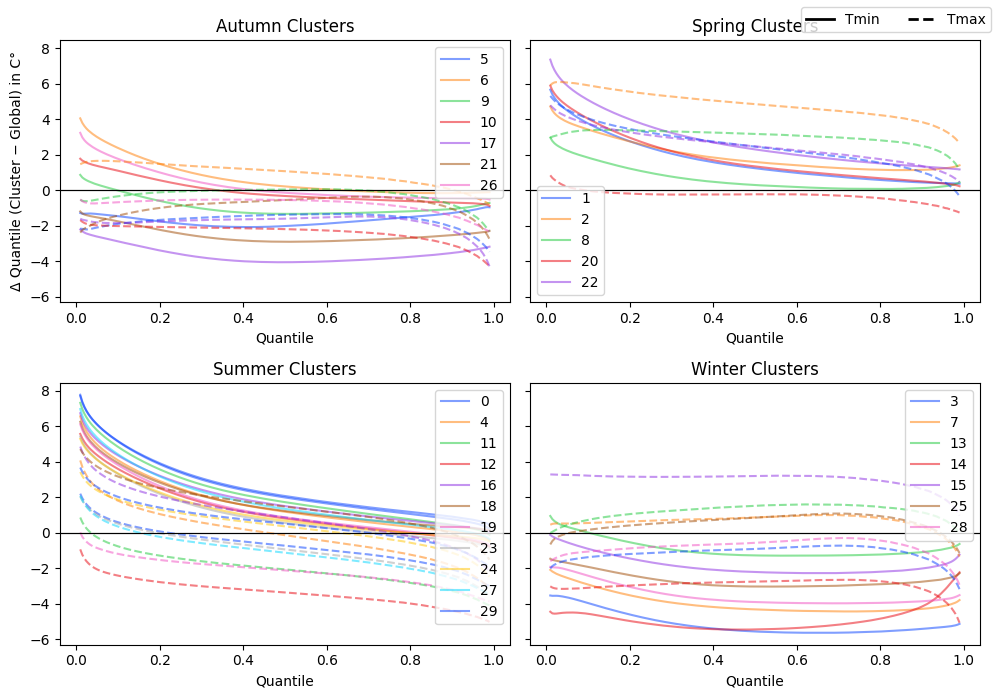

In [20]:
def quantile_all_groups(groups, n_quantiles=200):

    q = np.linspace(0.01, 0.99, n_quantiles)

    legend_position = {'Autumn': 'upper right',
            'Spring': 'lower left',
            'Summer': 'upper right',
            'Winter': 'upper right'}
                

    fig, axes = plt.subplots(2, len(groups)//2, figsize=(10, 7), sharey=True)
    axes = np.atleast_1d(axes)
    
    linestyles = ['solid', 'dashed', 'dotted', 'dashdot']
    
    for var in range(len(vars_names)):
        
        global_data = combined_dataset[:, var, :, :].ravel()
        global_q = np.quantile(global_data, q)

        for ax_id, (name, group) in enumerate(groups.items()):
            possible_colors = sns.color_palette("bright", n_colors=len(group))
            
            ax = axes.flatten()[ax_id]
            for g in group:
                color = possible_colors[group.index(g)]
                idx = df[df['cluster_id'] == g].index.values
                data = combined_dataset[:, var, :, :][idx].ravel()
                
                qg = np.quantile(data, q)
                ax.plot(q, qg - global_q, alpha=0.5, color=color, linestyle=linestyles[var]) 

            ax.axhline(0, color='black', lw=0.8)
            ax.set_xlabel("Quantile")
            ax.set_title(f"{name} Clusters")
            ax.legend([g for g in group], loc=legend_position.get(name, 'upper right'))
            
    axes.flatten()[0].set_ylabel("Δ Quantile (Cluster − Global) in C°") #celsius
    # plt.suptitle("Distribution Deviation per Season Groups")

    # add legend for variable line styles
    var_handles = [plt.Line2D([0], [0], color='black', lw=2, linestyle=linestyles[v]) for v in range(len(vars_names))]
    # legend on the right side of the figure
    fig.legend(var_handles, vars_names, loc='upper right',  ncol=len(vars_names)) 

    plt.tight_layout()
    plt.show()
quantile_all_groups(groups=grupos_map_season)  

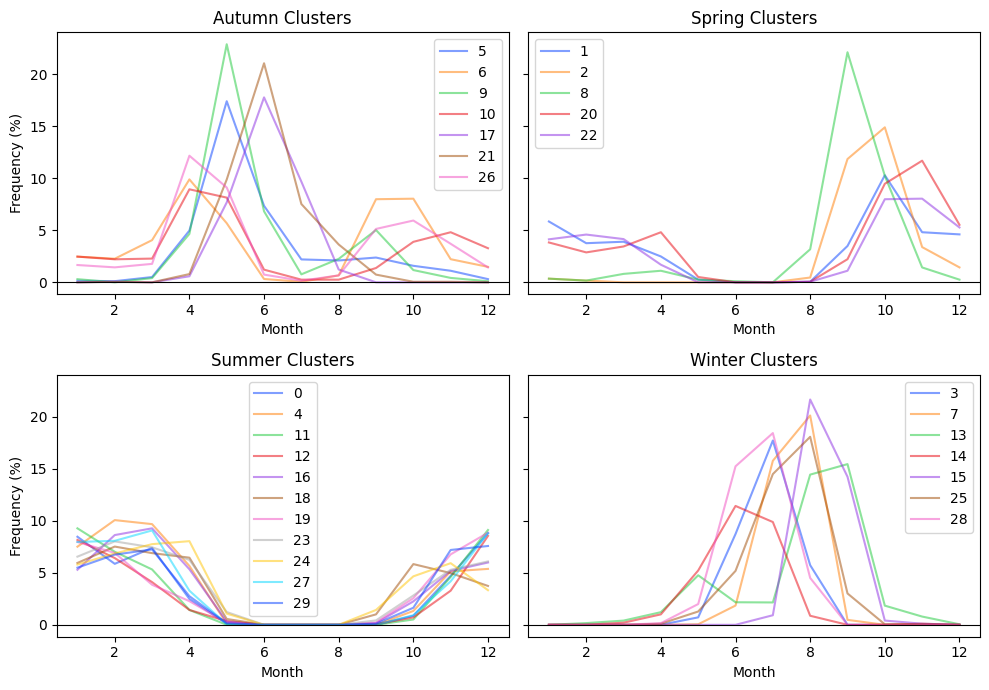

In [21]:
def freq_all_groups(groups):

    legend_position = {'Autumn': 'upper right',
            'Spring': 'upper left',
            'Summer': 'upper center',
            'Winter': 'upper right'}
                

    fig, axes = plt.subplots(2, len(groups)//2, figsize=(10, 7), sharey=True)
    axes = np.atleast_1d(axes)
    
    cur_df = df.copy()
    cur_df['month'] = cur_df['date'].dt.month
    month_freq = pd.crosstab(cur_df['month'], cur_df['cluster_id'], normalize='index')*100

    
    for ax_id, (name, group) in enumerate(groups.items()):
        # possible_colors = 
        ax= axes.flatten()[ax_id]
        month_freq.loc[:,group].plot(
            ax=ax,
            alpha=0.5,
            color=sns.color_palette("bright", n_colors=len(group)))
        
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xlabel("Month")
        ax.set_title(f"{name} Clusters")
        ax.legend([g for g in group], loc=legend_position.get(name, 'upper right'))
        
    axes.flatten()[0].set_ylabel("Frequency (%)") 
    axes.flatten()[2].set_ylabel("Frequency (%)") 
    # plt.suptitle("Monthly Historical Frequency of Clusters")


    plt.tight_layout()
    plt.show()
freq_all_groups(grupos_map_season)

El Nino Analysis

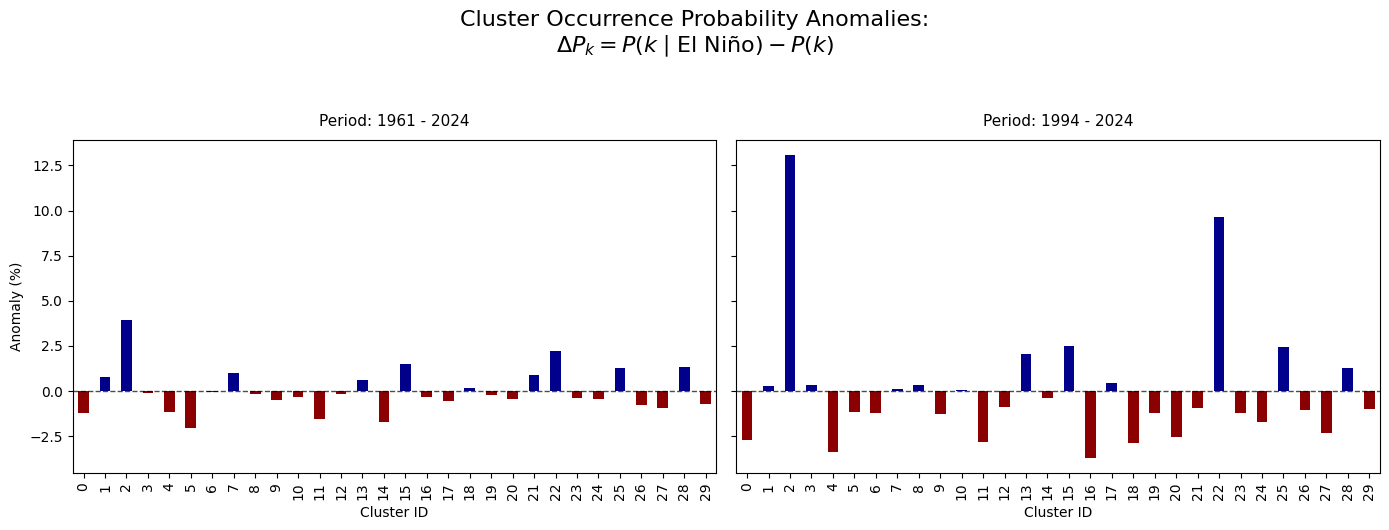

In [87]:
# Filtro dos dados
datasets = [
    (df_el_nino, df_el_nino['date'].dt.year.min(), df_el_nino['date'].dt.year.max()),
    (df_el_nino.query("1994 <= date.dt.year <= 2024"), 1994, 2024)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Título Principal
fig.suptitle(
    "Cluster Occurrence Probability Anomalies:\n"
    "$\\Delta P_k = P(k \\mid \\text{El Niño}) - P(k)$",
    fontsize=16, y=1.05
)

for ax, (data, start, end) in zip(axes, datasets):
    
    # P(k | El Niño)
    prob = pd.crosstab(data['Label'], data['cluster_id'], normalize='index')
    p_el_nino = prob.loc["El Niño"]
    
    # P(k) climatology
    p_clim = data['cluster_id'].value_counts(normalize=True)
    
    # Align indices (important!)
    p_clim = p_clim.reindex(p_el_nino.index, fill_value=0)
    
    # Anomaly
    anomaly = (p_el_nino - p_clim) * 100
    
    # Plot
    colors = ['darkblue' if v >= 0 else 'darkred' for v in anomaly.values]
    anomaly.plot(kind='bar', color=colors, ax=ax)
    
    # Subtítulo com as datas
    ax.set_title(f"Period: {start} - {end}", fontsize=11, pad=10)
    
    ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.7)
    ax.set_ylabel('Anomaly (%)' if ax == axes[0] else "")
    ax.set_xlabel('Cluster ID')

plt.tight_layout()
plt.show()

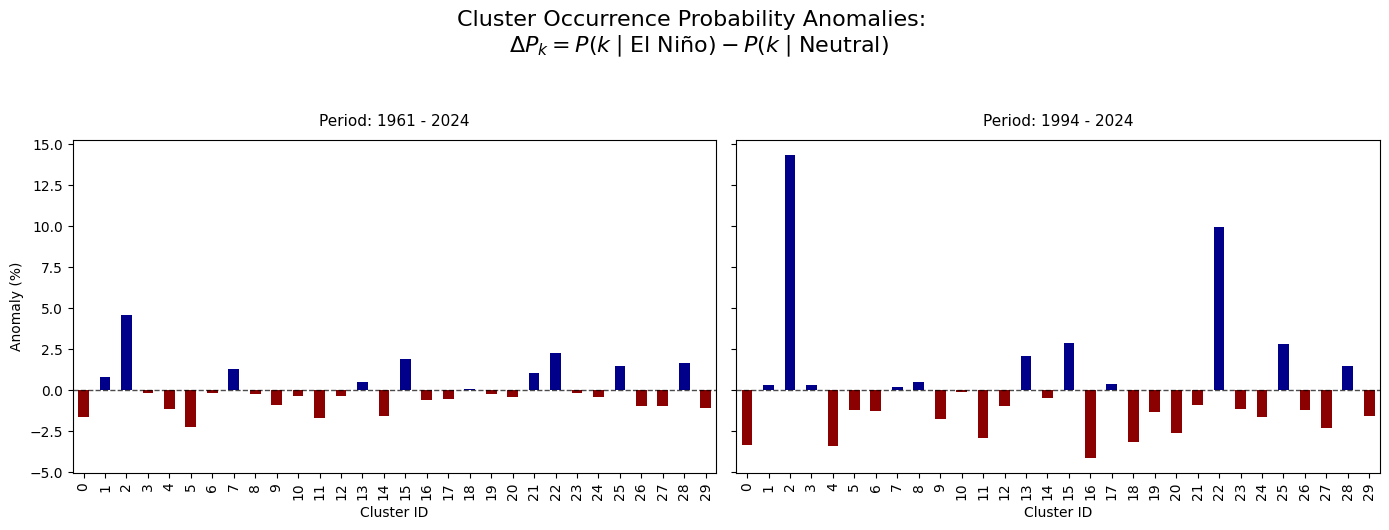

In [88]:
# Filtro dos dados
datasets = [
    (df_el_nino, df_el_nino['date'].dt.year.min(), df_el_nino['date'].dt.year.max()),
    (df_el_nino.query("1994 <= date.dt.year <= 2024"), 1994, 2024)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Título Principal
fig.suptitle("Cluster Occurrence Probability Anomalies: \n $\Delta P_k = P(k \mid \\text{El Niño}) - P(k \mid \\text{Neutral})$", 
             fontsize=16, y=1.05)

for ax, (data, start, end) in zip(axes, datasets):
    # Cálculo
    prob = pd.crosstab(data['Label'], data['cluster_id'], normalize='index') * 100
    anomaly = prob.loc["El Niño"] - prob.loc["Neutro"]
    
    # Plot
    colors = ['darkblue' if v >= 0 else 'darkred' for v in anomaly.values]
    anomaly.plot(kind='bar', color=colors, ax=ax)
    
    # Subtítulo com as datas
    ax.set_title(f"Period: {start} - {end}", fontsize=11, pad=10)
    
    ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.7)
    ax.set_ylabel('Anomaly (%)' if ax == axes[0] else "")
    ax.set_xlabel('Cluster ID')
    

plt.tight_layout()
plt.show()

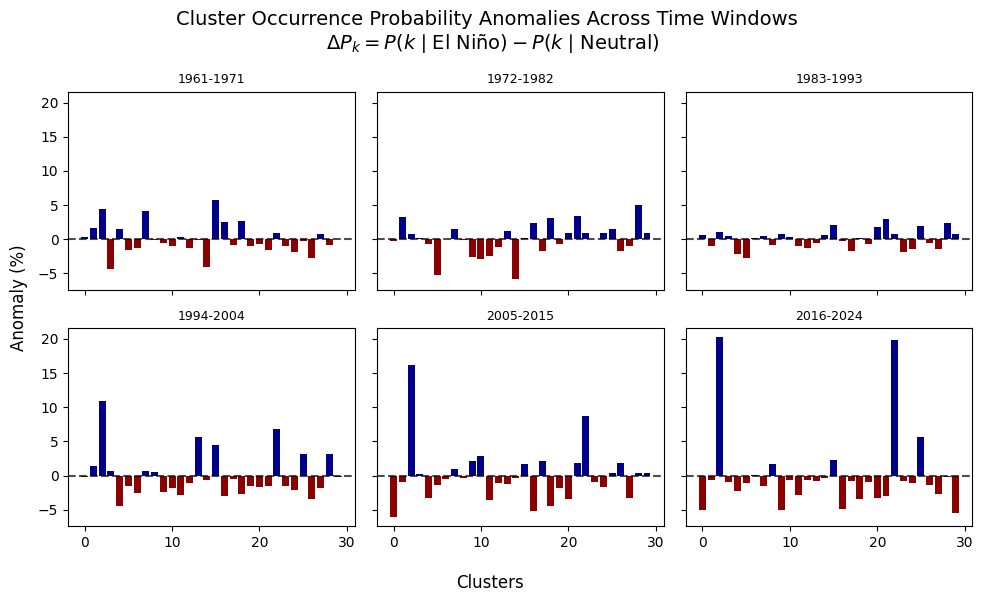

In [ ]:
import math

# ---- PARAMETERS ----
window_size = 11

# ---- COMPUTE ANOMALIES PER WINDOW ----
all_vals = []
labels = []

years = range(
    int(df_el_nino['date'].dt.year.min()),
    int(df_el_nino['date'].dt.year.max()),
    window_size
)

for start_year in years:
    end_year =  start_year + window_size
    cur_df = df_el_nino[
        (df_el_nino['date'].dt.year >= start_year) &
        (df_el_nino['date'].dt.year < end_year if end_year<2024 else 2025)
    ]

    if len(cur_df) == 0:
        continue

    conditional_proba = pd.crosstab(
        cur_df['Label'], cur_df['cluster_id'], normalize='index'
    ) * 100
    
    if not {"El Niño", "Neutro"}.issubset(conditional_proba.index):
        continue

    anomaly = conditional_proba.loc["El Niño"] - conditional_proba.loc["Neutro"]

    all_vals.append(anomaly)
    labels.append(f"{start_year}-{cur_df['date'].dt.year.max()}")

df_anomaly_time = pd.DataFrame(all_vals, index=labels)

# ---- GLOBAL Y LIMIT ----
max_abs = df_anomaly_time.abs().max().max()

# ---- 4x4 GRID ----
n_plots = min(16, len(df_anomaly_time))
fig, axes = plt.subplots(math.ceil(len(years)/3), 3, figsize=(10, 6), sharey=True, sharex=True)
axes = axes.flatten()

for i in range(n_plots):
    ax = axes[i]
    vals = df_anomaly_time.iloc[i]

    colors = ['darkblue' if v >= 0 else 'darkred' for v in vals.values]

    ax.bar(vals.index, vals.values, color=colors)
    ax.axhline(0, color='black', linestyle='--', alpha=0.7)

    ax.set_title(df_anomaly_time.index[i], fontsize=9)
    # ax.set_ylim(-max_abs, max_abs)

    # Optional: reduce clutter
    # ax.set_xticks([])

# Remove empty subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Cluster Occurrence Probability Anomalies Across Time Windows \n $\Delta P_k = P(k \mid \\text{El Niño}) - P(k \mid \\text{Neutral})$', fontsize=14)
fig.supxlabel('Clusters')
fig.supylabel('Anomaly (%)')

plt.tight_layout()
plt.show()

El Nino effect could not be immediate;

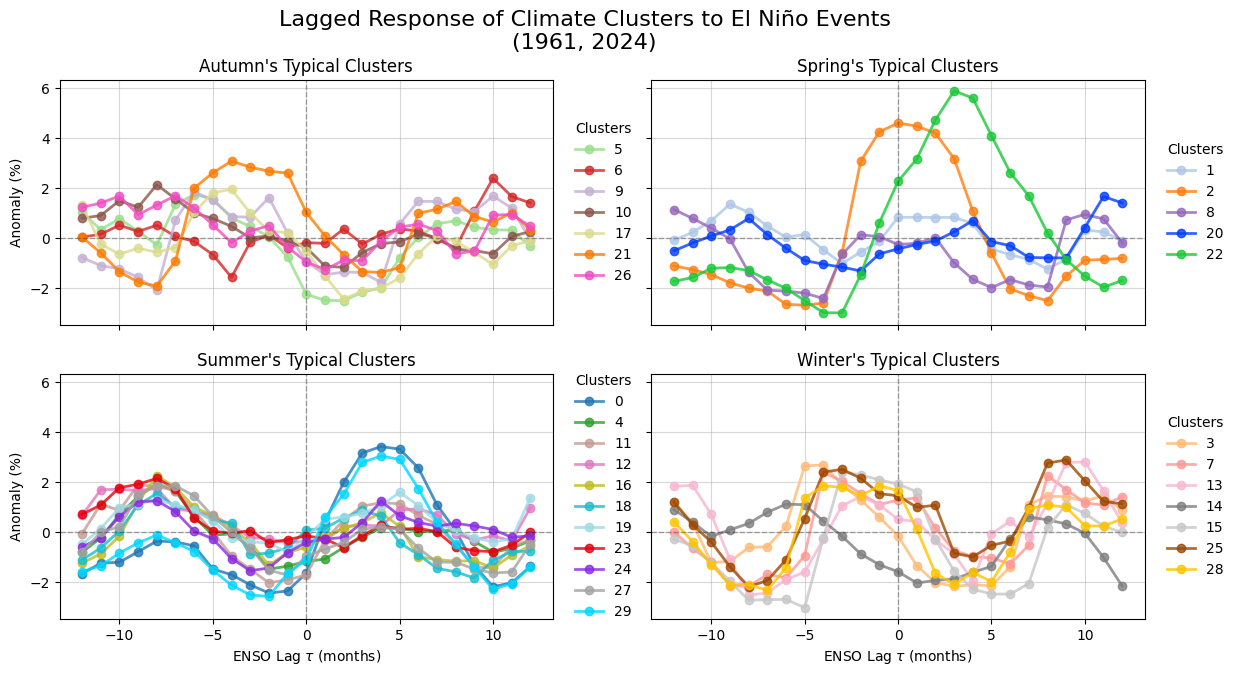

In [ ]:
import pandas as pd
df['date_period'] = df['date'].dt.to_period('M')

def get_anon(df):
    anomalias_list = {}

    for lag in range(-12, 13):

        df_el_nino = df.copy()
        df_el_nino = df_el_nino.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')
        
        conditional_proba = pd.crosstab(df_el_nino['Label'], df_el_nino['cluster_id'],normalize='index') * 100
        anomalias_list[lag] = conditional_proba.loc["El Niño"]  - conditional_proba.loc["Neutro"] 

    anom = pd.DataFrame(anomalias_list).sort_index(axis=1)
    anom.columns.name = 'Lag'
    return anom

cur_df = df.copy()
anom = get_anon(cur_df)
pallete30 = sns.color_palette("tab20", 20) + sns.color_palette("bright", 10)
fig, axes = plt.subplots(2,2, figsize=(14, 7),sharex=True, sharey=True)

axes = axes.flatten()

for idx, (season, cur_clusters) in enumerate(grupos_map_season.items()):

    anom.T[cur_clusters].plot(
        marker='o',
        lw=2,
        alpha=0.8,
        ax=axes[idx],
        color=[pallete30[i] for i in cur_clusters],
    )
    
    axes[idx].axhline(0, color='black', lw=1, linestyle='--', alpha=0.3)
    axes[idx].axvline(0, color='black', lw=1, linestyle='--',  alpha=0.3)
    axes[idx].grid(True, alpha=0.5)
    # axes[idx].set_ylim(-4, 10)
        
    axes[idx].set_title(f"{season}'s Typical Clusters")
    axes[idx].set_ylabel('Anomaly (%)')
    axes[idx].set_xlabel('ENSO Lag $\\tau$ (months)')

    axes[idx].legend(
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            title="Clusters"
        )
    
year_s, year_e = cur_df['date'].dt.year.min(), cur_df['date'].dt.year.max()
formula_subtitle = "$\Delta P_k(\\tau) = P(k \mid \\text{El Niño}_\\tau) - P(k \mid \\text{Neutral}_\\tau)$"
fig.suptitle(f'Lagged Response of Climate Clusters to El Niño Events\n({year_s}, {year_e})',fontsize=16)
plt.show()


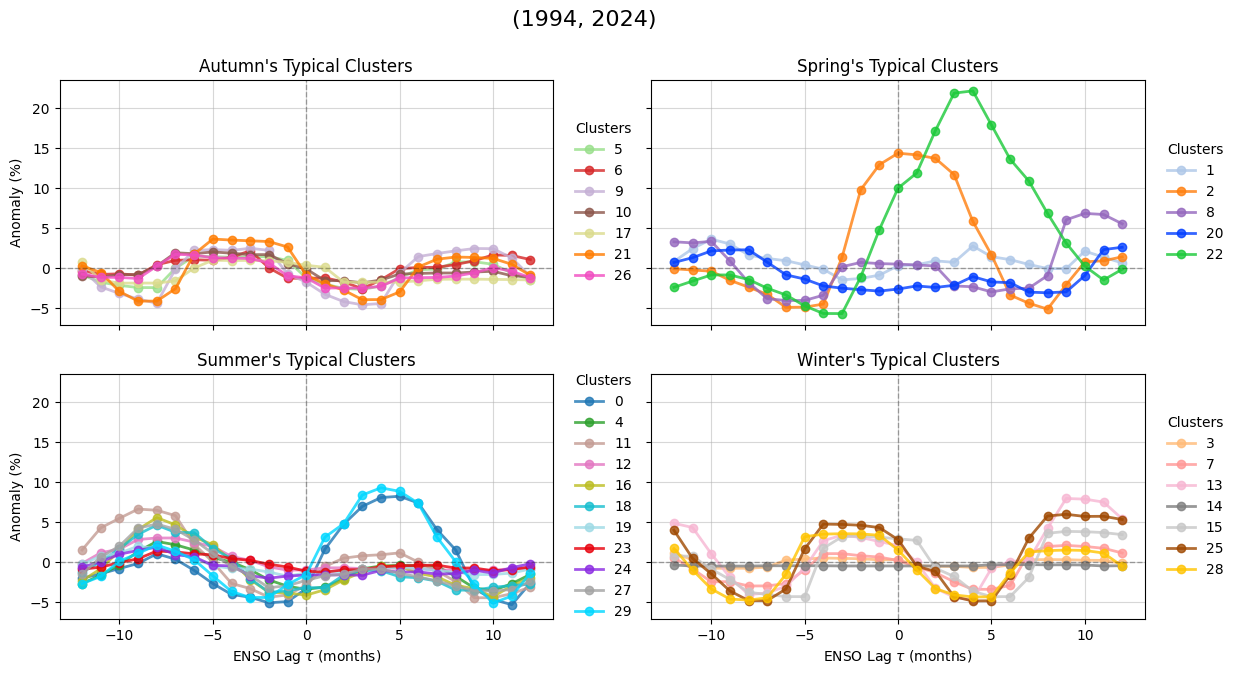

In [26]:
cur_df = df[df['date'].dt.year>=1994]
anom = get_anon(cur_df)
pallete30 = sns.color_palette("tab20", 20) + sns.color_palette("bright", 10)
fig, axes = plt.subplots(2,2, figsize=(14, 7),sharex=True, sharey=True)

axes = axes.flatten()

for idx, (season, cur_clusters) in enumerate(grupos_map_season.items()):

    anom.T[cur_clusters].plot(
        marker='o',
        lw=2,
        alpha=0.8,
        ax=axes[idx],
        color=[pallete30[i] for i in cur_clusters],
    )
    
    axes[idx].axhline(0, color='black', lw=1, linestyle='--', alpha=0.3)
    axes[idx].axvline(0, color='black', lw=1, linestyle='--',  alpha=0.3)
    axes[idx].grid(True, alpha=0.5)
    # axes[idx].set_ylim(-5, 10)
        
    axes[idx].set_title(f"{season}'s Typical Clusters")
    axes[idx].set_ylabel('Anomaly (%)')
    axes[idx].set_xlabel('ENSO Lag $\\tau$ (months)')

    axes[idx].legend(
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            title="Clusters"
        )
    
year_s, year_e = cur_df['date'].dt.year.min(), cur_df['date'].dt.year.max()
formula_subtitle = "$\Delta P_k(\\tau) = P(k \mid \\text{El Niño}_\\tau) - P(k \mid \\text{Neutral}_\\tau)$"
fig.suptitle(f'({year_s}, {year_e})',fontsize=16)
plt.show()

Can we remove the effect of climatlogy?

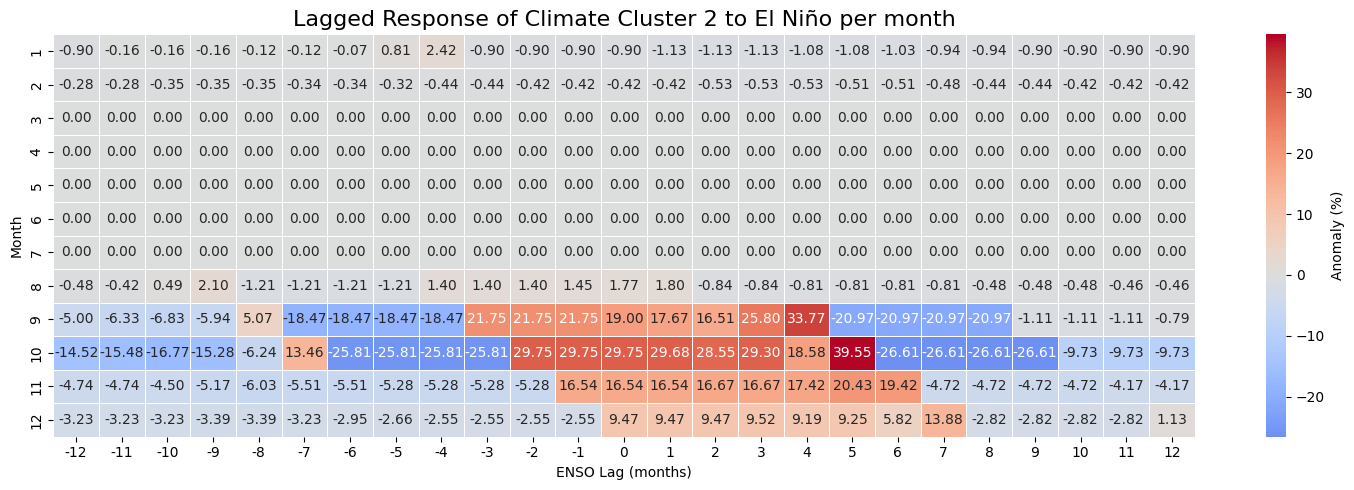

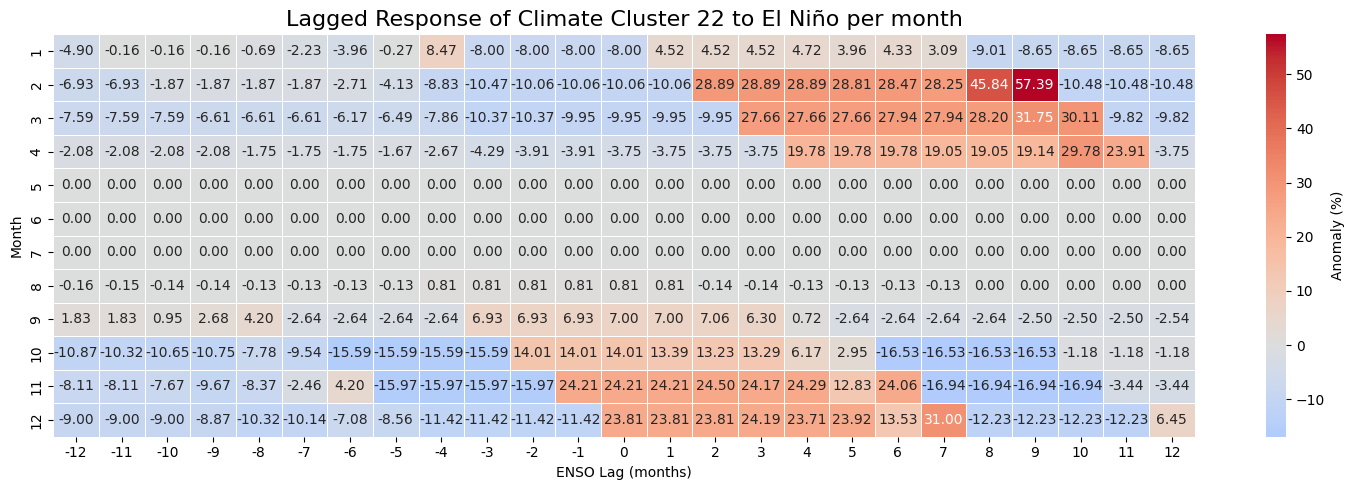

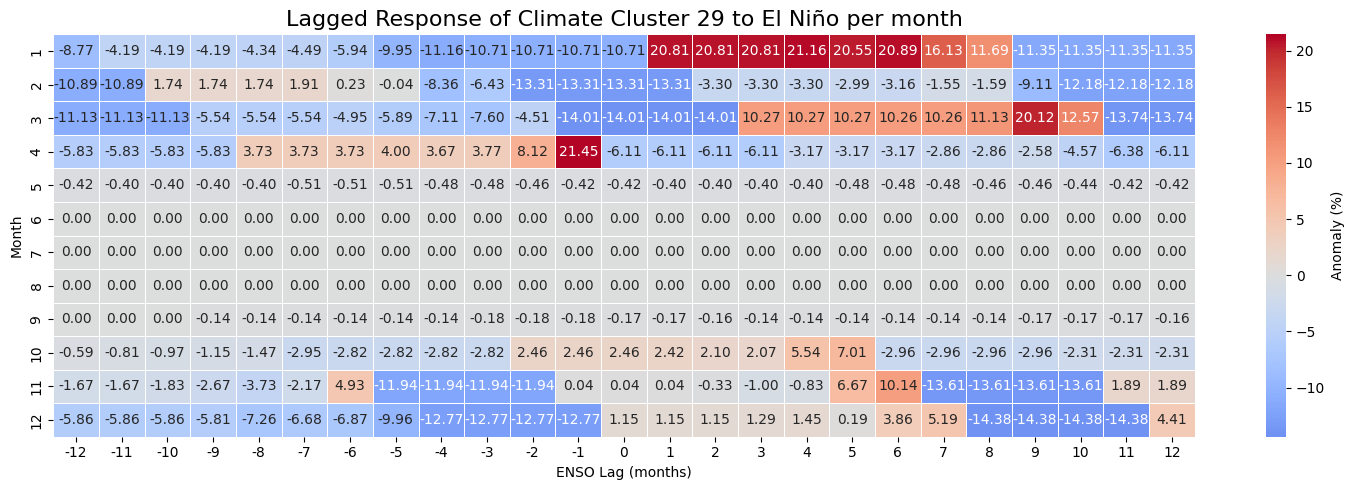

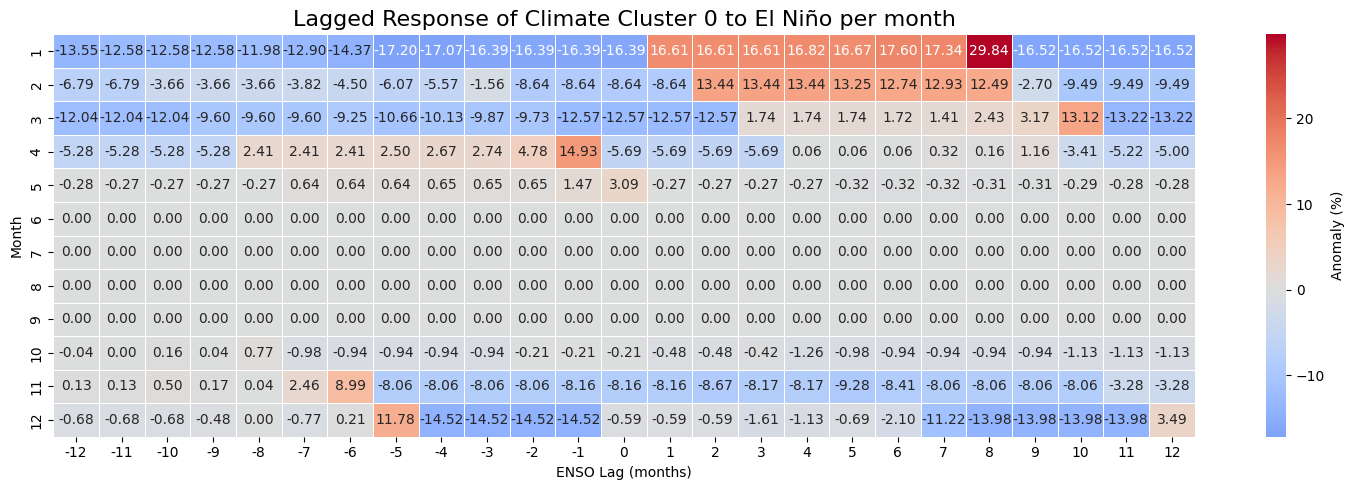

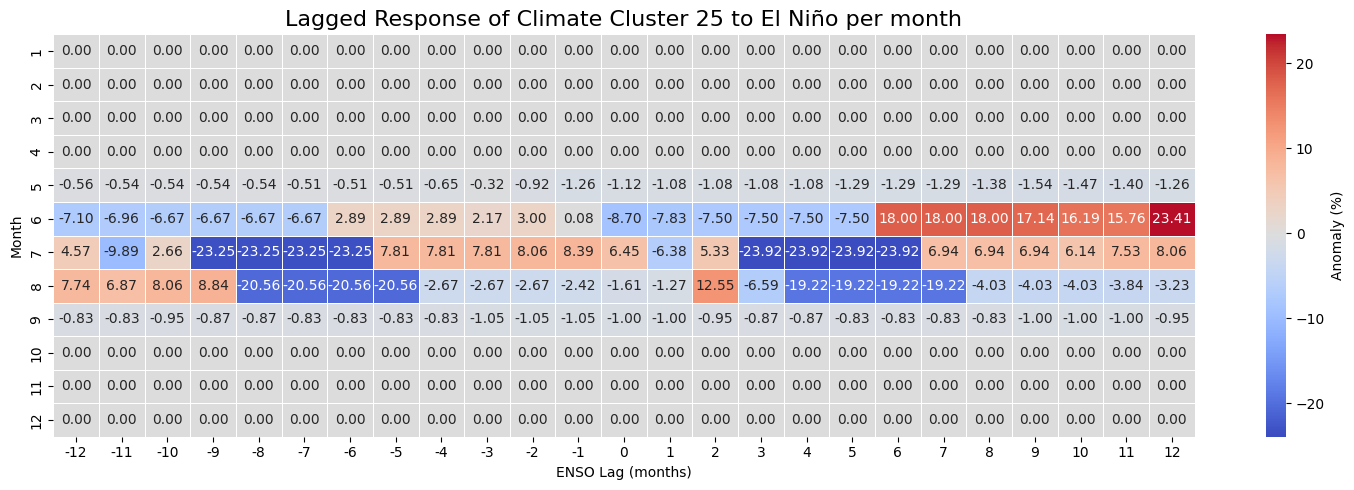

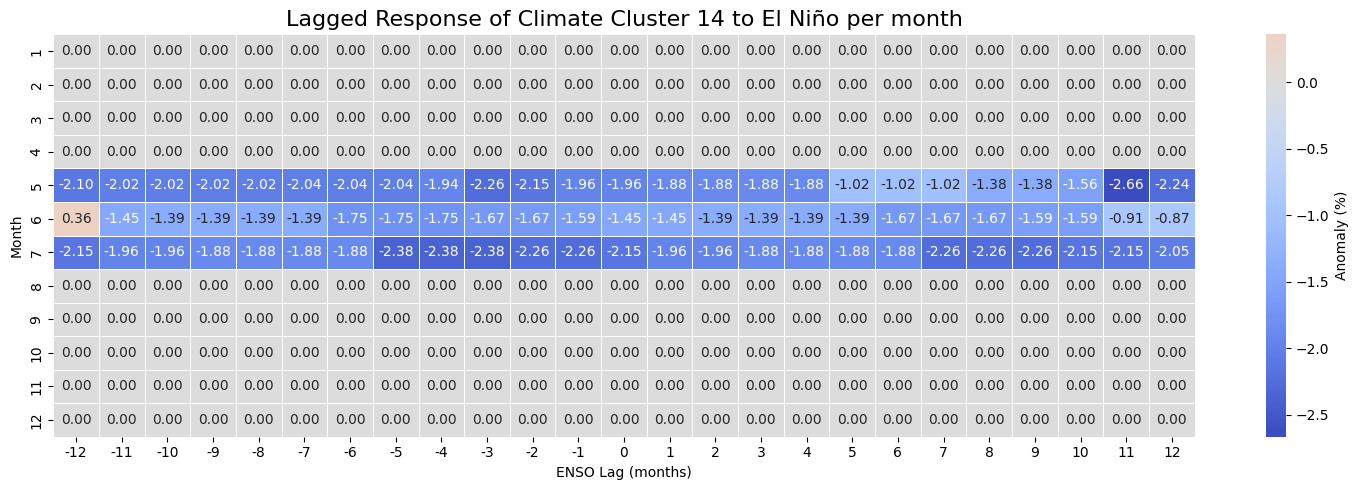

In [43]:
# df['month'] = df.index.month
# cur_df = df[df.index.year>=1994]

for cur_cluster in [2,22,29,0,25,14]:

    climate_anon = {}

    for month in range(1,13):
        for lag in range(-12, 13):
            
            df_heatmap = df[df.index.year>=1994].drop(['Label','ONI','is_target','label_color'],axis=1,errors='ignore').copy()
            df_heatmap = df_heatmap.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')
            
            cur_df = df_heatmap[(df_heatmap['Label']=="El Niño") & (df_heatmap['month']==month)] 
            p_cluster_nino_m = cur_df[cur_df['cluster_id']==cur_cluster].shape[0]/cur_df.shape[0] if cur_df.shape[0] > 0 else 0 #P(cluster=k | El Niño, month=m)

            cur_df = df_heatmap[(df_heatmap['Label']=="Neutro") & (df_heatmap['month']==month)] 
            p_cluster_m = cur_df[cur_df['cluster_id']==cur_cluster].shape[0]/cur_df.shape[0] if cur_df.shape[0] > 0 else 0 #P(cluster=c | month=m)
            
            climate_anon[(month, lag)] = (p_cluster_nino_m - p_cluster_m)*100

            
    # Convertendo o dicionário para um DataFrame
    climate_anon_df = pd.DataFrame.from_dict(climate_anon, orient='index', columns=['Anomaly'])
    climate_anon_df.index = pd.MultiIndex.from_tuples(climate_anon_df.index, names=['Month', 'Lag'])
    climate_anon_df = climate_anon_df.reset_index()    


    #heatmap
    pivot_table = climate_anon_df.pivot(index='Month', columns='Lag', values='Anomaly',) 
    plt.figure(figsize=(15, 5))
    
    sns.heatmap(pivot_table, cmap='coolwarm', center=0, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Anomaly (%)'})
    
    prob_descr = "$\Delta P_k(\\tau, \\text{month}) = P(k \mid \\text{El Niño}_\\tau, \\text{month}) - P(k \mid \\text{Neutral}_\\tau, \\text{month})$"
    
    plt.title(f'Lagged Response of Climate Cluster {cur_cluster} to El Niño per month',fontsize=16)
    plt.ylabel('Month')
    plt.xlabel('ENSO Lag (months)')
    plt.tight_layout()

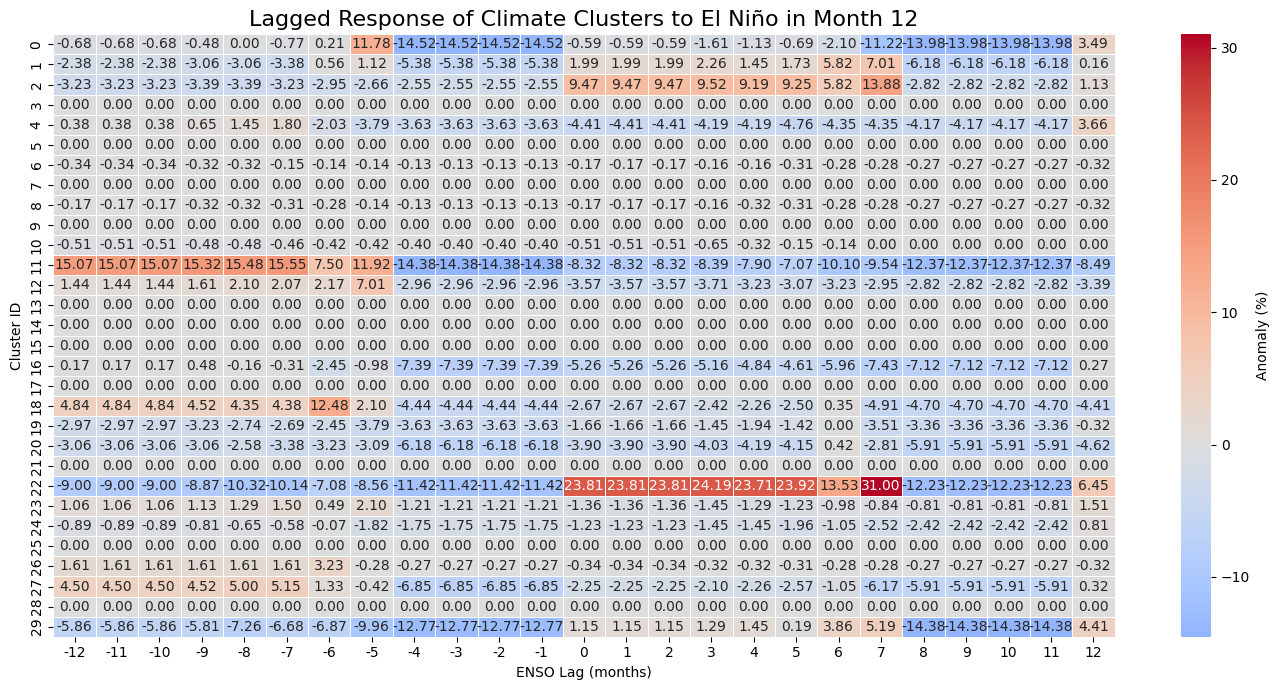

In [44]:

for month in [12]:

    climate_anon = {}

    for cur_cluster in range(30):
        for lag in range(-12, 13):
            
            df_heatmap = df[df.index.year>=1994].drop(['Label','ONI','is_target','label_color'],axis=1,errors='ignore').copy()
            df_heatmap = df_heatmap.merge(oni_index.shift(lag).dropna(), left_on='date_period', right_index=True, how='left')
            
            cur_df = df_heatmap[(df_heatmap['Label']=="El Niño") & (df_heatmap['month']==month)] 
            p_cluster_nino_m = cur_df[cur_df['cluster_id']==cur_cluster].shape[0]/cur_df.shape[0] if cur_df.shape[0] > 0 else 0 #P(cluster=k | El Niño, month=m)

            cur_df = df_heatmap[(df_heatmap['Label']=="Neutro") & (df_heatmap['month']==month)] 
            p_cluster_m = cur_df[cur_df['cluster_id']==cur_cluster].shape[0]/cur_df.shape[0] if cur_df.shape[0] > 0 else 0 #P(cluster=c | month=m)
            
            climate_anon[(cur_cluster, lag)] = (p_cluster_nino_m - p_cluster_m)*100

            
    # Convertendo o dicionário para um DataFrame
    climate_anon_df = pd.DataFrame.from_dict(climate_anon, orient='index', columns=['Anomaly'])
    climate_anon_df.index = pd.MultiIndex.from_tuples(climate_anon_df.index, names=['Cluster', 'Lag'])
    climate_anon_df = climate_anon_df.reset_index()    


    #heatmap
    pivot_table = climate_anon_df.pivot(index='Cluster', columns='Lag', values='Anomaly') 
    plt.figure(figsize=(14,7))
    sns.heatmap(pivot_table, cmap='coolwarm', center=0, annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Anomaly (%)'})
    
    prob_descr = "$\Delta P_k(\\tau, \\text{month}) = P(k \mid \\text{El Niño}_\\tau, \\text{month}) - P(k \mid \\text{Neutral}_\\tau, \\text{month})$"
    
    plt.title(f'Lagged Response of Climate Clusters to El Niño in Month {month}',fontsize=16)
    plt.ylabel('Cluster ID')
    plt.xlabel('ENSO Lag (months)')
    plt.tight_layout()

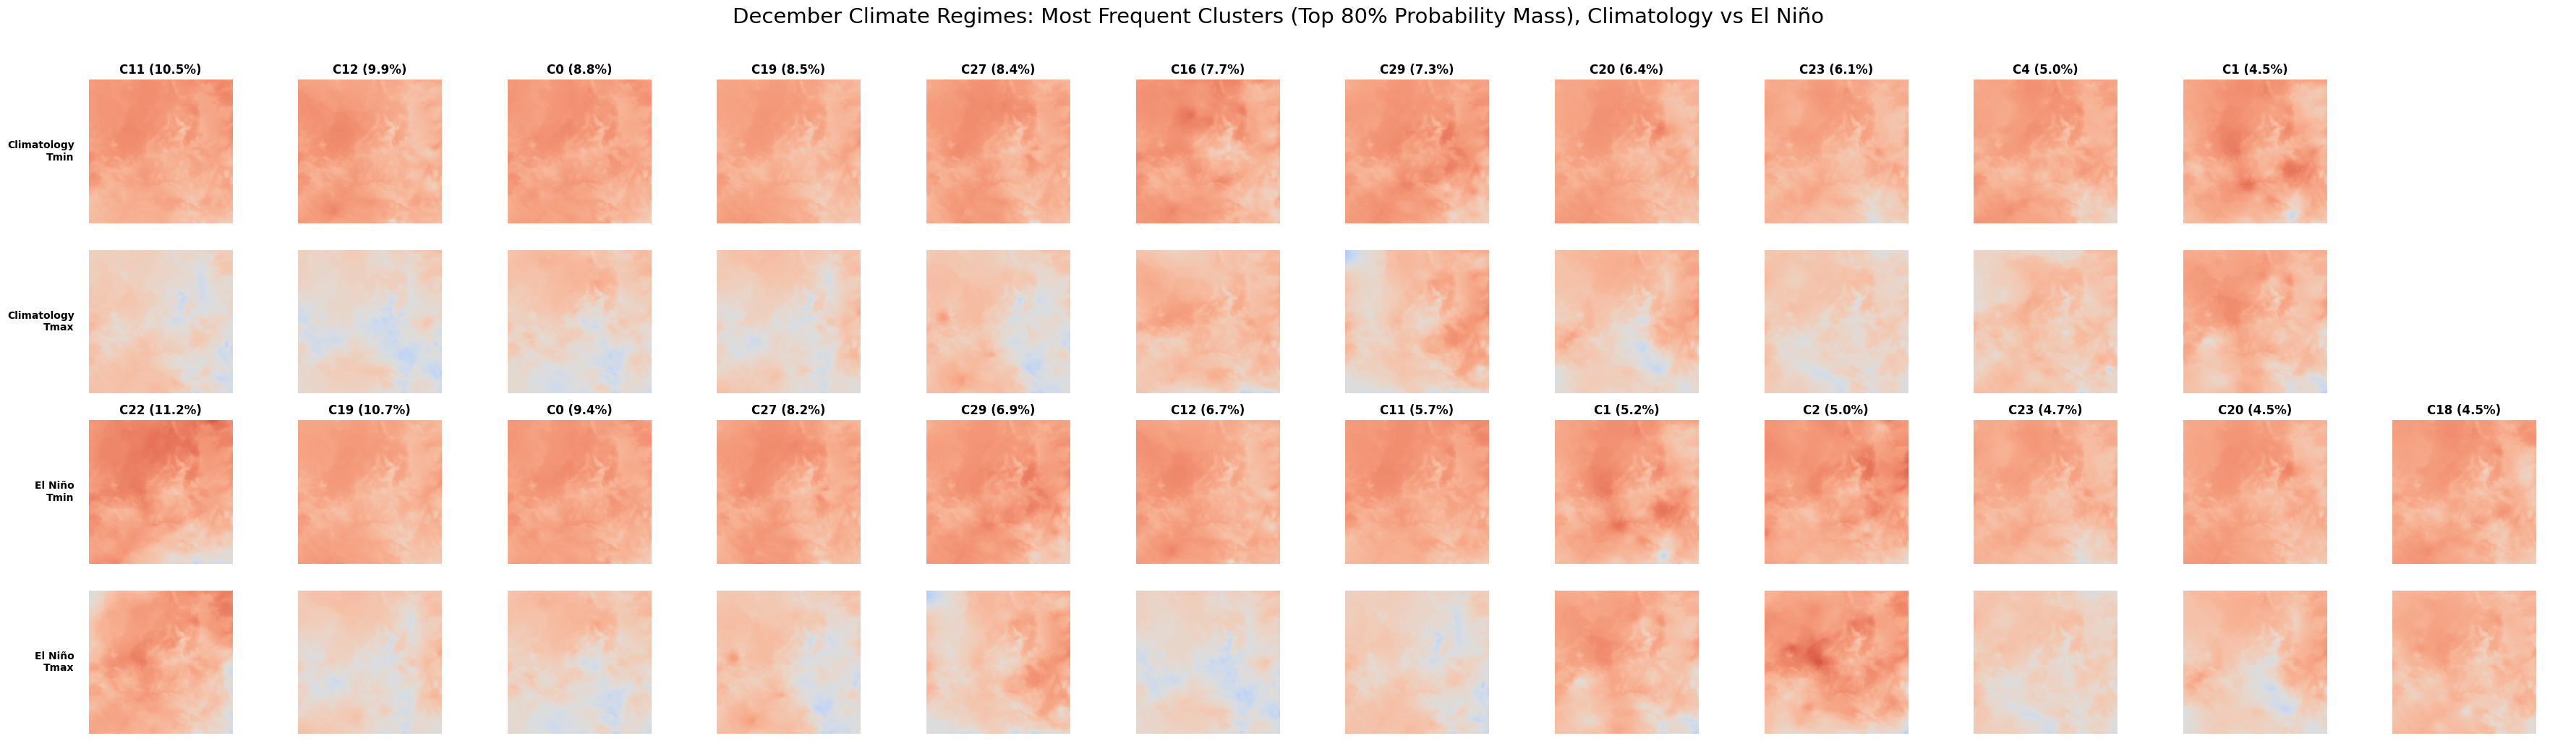

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_dec = df_el_nino[df_el_nino['date'].dt.month == 12].copy()
df_dec_clim =df_dec[df_dec['Label'] == 'Neutro']
df_dec_nino = df_dec[df_dec['Label'] == 'El Niño']

def get_top_80_clusters(df_cond):
    dist = df_cond['cluster_id'].value_counts(normalize=True)
    cumsum = dist.cumsum()
    top_clusters = []
    for cluster, cum_val in cumsum.items():
        top_clusters.append(cluster)
        if cum_val >= 0.8:
            break
    return top_clusters, dist

top_clim, dist_clim = get_top_80_clusters(df_dec_clim)
top_nino, dist_nino = get_top_80_clusters(df_dec_nino)

max_cols = max(len(top_clim), len(top_nino))
total_rows = 2 * nvars # Metade das linhas para Neutro, metade para El Niño

# squeeze=False previne erros se max_cols for igual a 1
fig, axes = plt.subplots(total_rows, max_cols, figsize=(3 * max_cols, 2.5 * total_rows), squeeze=False)

# --- PLOT: Climatologia (Neutro) ---
for idx in range(max_cols):
    if idx < len(top_clim):
        cluster_id = top_clim[idx]
        prob = dist_clim[cluster_id] * 100
        sample = df_el_nino[df_el_nino['cluster_id'] == cluster_id].nlargest(1, 'cluster_prob')
        
        if not sample.empty:
            im_idx = sample.index[0]
            image_data = combined_dataset[im_idx]
            
            for var in range(nvars):
                ax = axes[var, idx] # Aloca nas linhas superiores (0 até nvars-1)
                vmin, vmax = var_stats[var]
                ax.imshow(image_data[var], cmap='coolwarm', vmin=vmin, vmax=vmax)
                ax.axis('off')
                
                # Título apenas na primeira variável
                if var == 0:
                    ax.set_title(f"C{cluster_id} ({prob:.1f}%)", fontweight='bold')
                # Label lateral apenas na primeira coluna
                if idx == 0:
                    ax.text(-0.1, 0.5, f"Climatology\n{vars_names[var]}", transform=ax.transAxes, 
                            ha='right', va='center', fontweight='bold', fontsize=10)
    else:
        # Desliga os eixos excedentes se este cenário tiver menos clusters que o outro
        for var in range(nvars): axes[var, idx].axis('off')

# --- PLOT: El Niño ---
for idx in range(max_cols):
    if idx < len(top_nino):
        cluster_id = top_nino[idx]
        prob = dist_nino[cluster_id] * 100
        sample = df_el_nino[df_el_nino['cluster_id'] == cluster_id].nlargest(1, 'cluster_prob')
        
        if not sample.empty:
            im_idx = sample.index[0]
            image_data = combined_dataset[im_idx]
            
            for var in range(nvars):
                row_idx = nvars + var # Desloca as linhas para a parte inferior do grid
                ax = axes[row_idx, idx] 
                vmin, vmax = var_stats[var]
                ax.imshow(image_data[var], cmap='coolwarm', vmin=vmin, vmax=vmax)
                ax.axis('off')
                
                if var == 0:
                    ax.set_title(f"C{cluster_id} ({prob:.1f}%)", fontweight='bold')
                if idx == 0:
                    ax.text(-0.1, 0.5, f"El Niño\n{vars_names[var]}", transform=ax.transAxes, 
                            ha='right', va='center', fontweight='bold', fontsize=10)
    else:
        for var in range(nvars): axes[nvars + var, idx].axis('off')
plt.suptitle(
    "December Climate Regimes: Most Frequent Clusters (Top 80% Probability Mass), Climatology vs El Niño",
    fontsize=21, y=1.02
)
plt.tight_layout()
plt.show()

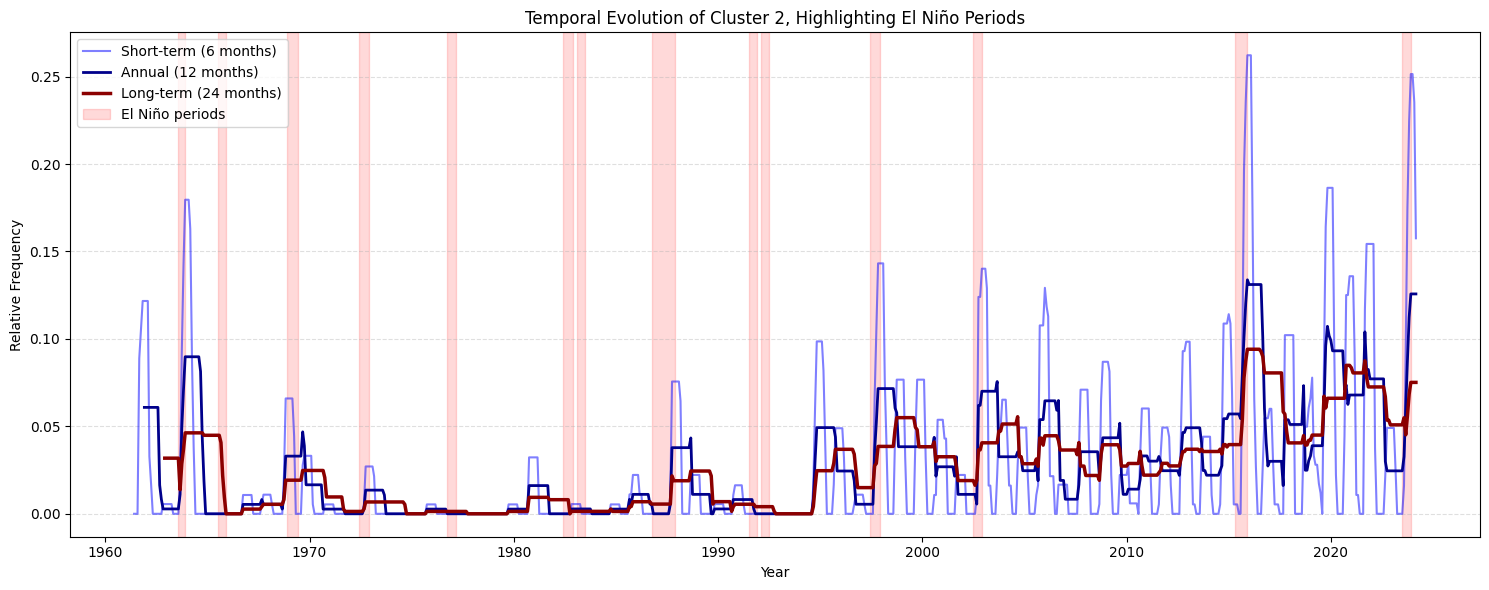

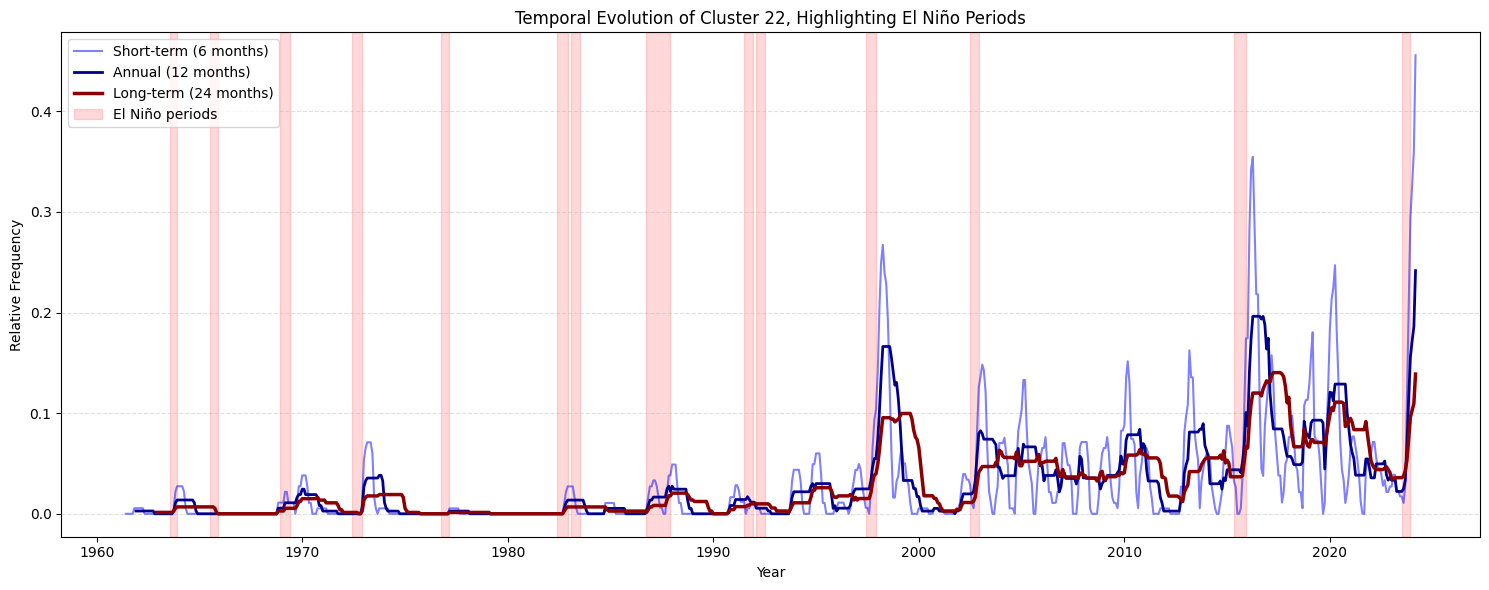

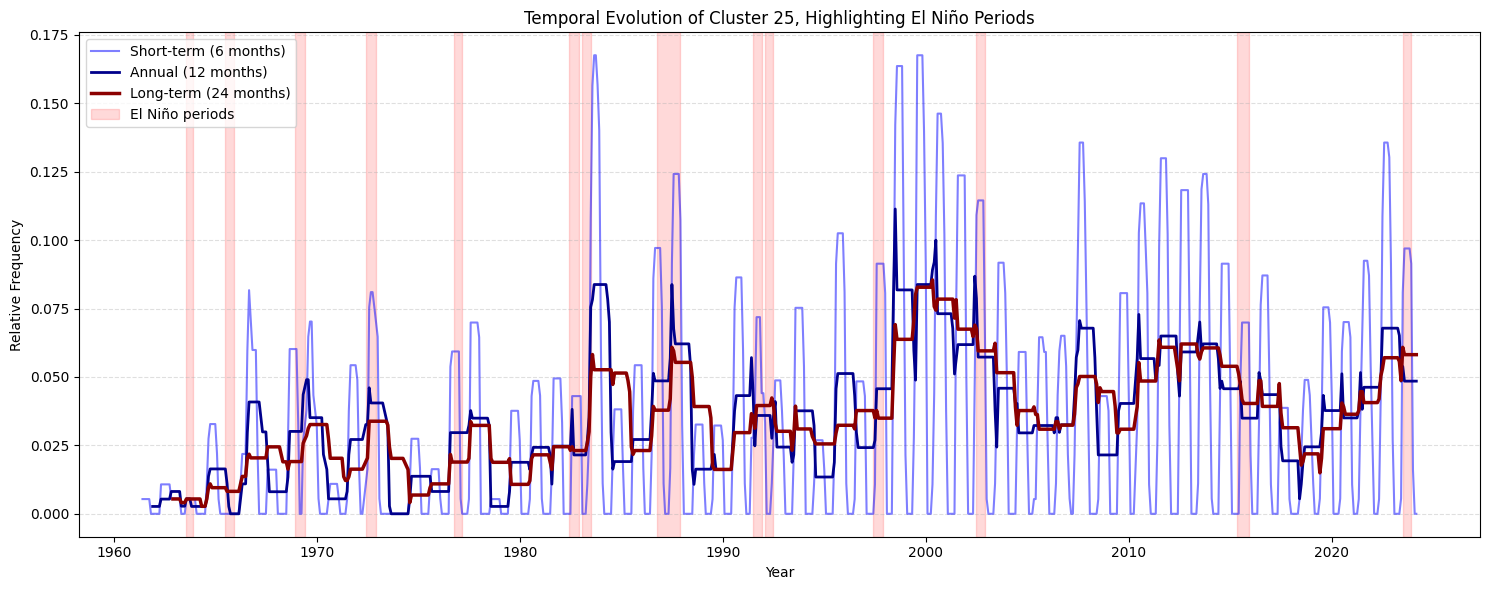

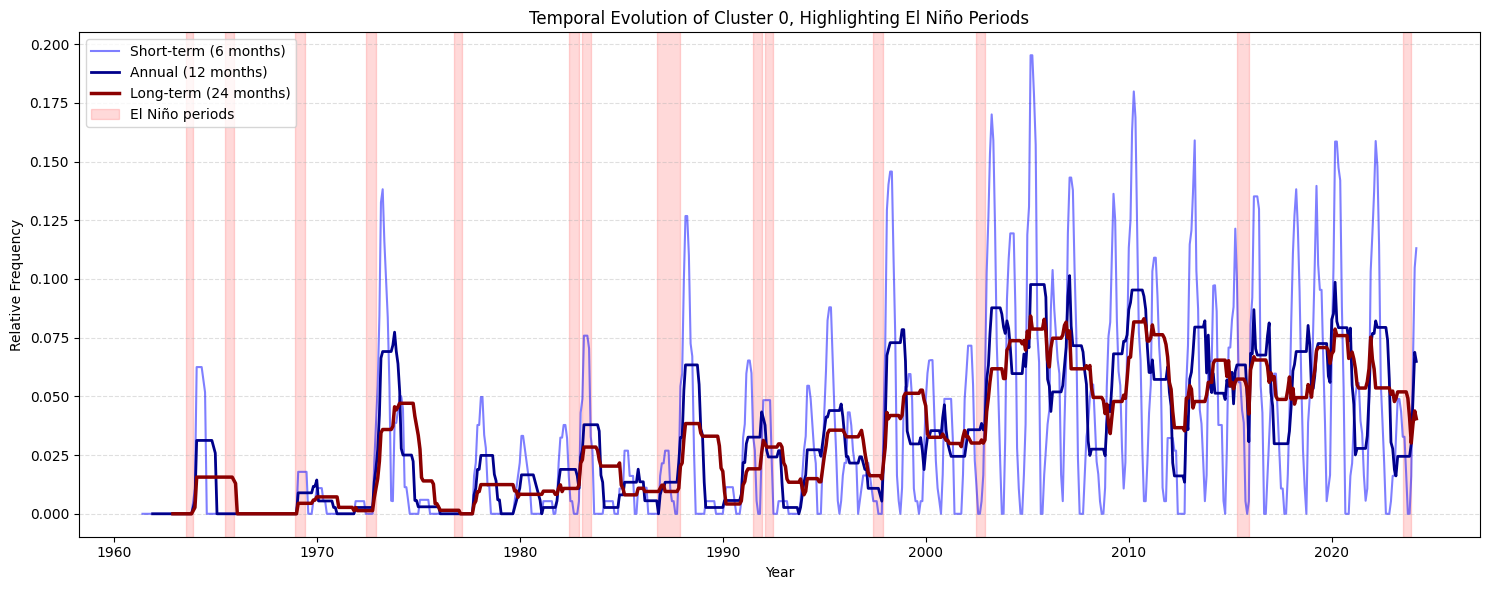

In [29]:
# Parâmetrosfor 
for target_cluster in [2,22,25,0]:

    # 1. Prepara os dados temporais mensais
    df = df_el_nino.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').set_index('date')

    # Cria uma variável binária para o cluster alvo (1 se ocorreu, 0 se não)
    df['is_target'] = (df['cluster_id'] == target_cluster).astype(int)

    # Agrupa por mês (garante que temos uma série contínua)
    df_monthly = df.resample('MS').agg({
        'is_target': 'mean', # Frequência do cluster no mês
        'Label': 'first'     # Mantém o estado climático do mês
    })

    # 2. Calcula as Médias Móveis
    df_monthly['MA_3m'] = df_monthly['is_target'].rolling(window=6).mean()
    df_monthly['MA_12m'] = df_monthly['is_target'].rolling(window=12).mean()
    df_monthly['MA_24m'] = df_monthly['is_target'].rolling(window=24).mean()


    plt.figure(figsize=(15, 6))

    # Trend lines
    plt.plot(df_monthly.index, df_monthly['MA_3m'], label='Short-term (6 months)', alpha=0.5, color='blue')
    plt.plot(df_monthly.index, df_monthly['MA_12m'], label='Annual (12 months)', linewidth=2, color='darkblue')
    plt.plot(df_monthly.index, df_monthly['MA_24m'], label='Long-term (24 months)', linewidth=2.5, color='darkred')

    # Shaded background for El Niño periods
    is_nino = df_monthly['Label'] == 'El Niño'
    plt.fill_between(
        df_monthly.index, 
        0, 1, 
        where=is_nino, 
        color='red', 
        alpha=0.15, 
        transform=plt.gca().get_xaxis_transform(), 
        label='El Niño periods'
    )

    plt.title(f"Temporal Evolution of Cluster {target_cluster}, Highlighting El Niño Periods")
    
    plt.ylabel("Relative Frequency")
    plt.xlabel("Year")
    plt.legend(loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()